# Distributions, Contours and Everything Else

In [28]:
import numpy as np
np.random.seed(1337)

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.style.use('ggplot')

In [79]:
num_bins = 100  # number of bins in each dimension, can be any like 5, 20, 50, 100
num_sample = 10000000

data = 100 + 10 * np.random.randn(num_sample, 2) # generates 10000000 2-D random data points
# distribution will be normal and number lies between 10 and 110.

joint_probs, edges = np.histogramdd(data, bins=num_bins)

edges = np.array(edges)[:,1:]

In [80]:
print(edges)

[[ 48.3178524   49.39392971  50.47000702  51.54608433  52.62216163
   53.69823894  54.77431625  55.85039356  56.92647087  58.00254817
   59.07862548  60.15470279  61.2307801   62.30685741  63.38293472
   64.45901202  65.53508933  66.61116664  67.68724395  68.76332126
   69.83939857  70.91547587  71.99155318  73.06763049  74.1437078
   75.21978511  76.29586241  77.37193972  78.44801703  79.52409434
   80.60017165  81.67624896  82.75232626  83.82840357  84.90448088
   85.98055819  87.0566355   88.13271281  89.20879011  90.28486742
   91.36094473  92.43702204  93.51309935  94.58917665  95.66525396
   96.74133127  97.81740858  98.89348589  99.9695632  101.0456405
  102.12171781 103.19779512 104.27387243 105.34994974 106.42602705
  107.50210435 108.57818166 109.65425897 110.73033628 111.80641359
  112.8824909  113.9585682  115.03464551 116.11072282 117.18680013
  118.26287744 119.33895474 120.41503205 121.49110936 122.56718667
  123.64326398 124.71934129 125.79541859 126.8714959  127.947573

In [81]:
joint_probs.shape

(100, 100)

In [82]:
joint_probs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100))

In [83]:
cut_point = int(num_bins/2)

X_vals = np.array( joint_probs[cut_point] )
X_vals /= X_vals.sum() # normalize btwn 0 and 1

# getting col out is difficult in python 2-D array, can be easily done in np but using composition

Y_vals = np.array( [row[cut_point] for row in joint_probs] )
Y_vals /= Y_vals.sum() # again normalize

In [84]:
print("Cut on X and Y on: ", cut_point)
print("Edges: ", edges[0])
print("X_vals: ", X_vals)
print("y_vals: ", Y_vals)

Cut on X and Y on:  50
Edges:  [ 48.3178524   49.39392971  50.47000702  51.54608433  52.62216163
  53.69823894  54.77431625  55.85039356  56.92647087  58.00254817
  59.07862548  60.15470279  61.2307801   62.30685741  63.38293472
  64.45901202  65.53508933  66.61116664  67.68724395  68.76332126
  69.83939857  70.91547587  71.99155318  73.06763049  74.1437078
  75.21978511  76.29586241  77.37193972  78.44801703  79.52409434
  80.60017165  81.67624896  82.75232626  83.82840357  84.90448088
  85.98055819  87.0566355   88.13271281  89.20879011  90.28486742
  91.36094473  92.43702204  93.51309935  94.58917665  95.66525396
  96.74133127  97.81740858  98.89348589  99.9695632  101.0456405
 102.12171781 103.19779512 104.27387243 105.34994974 106.42602705
 107.50210435 108.57818166 109.65425897 110.73033628 111.80641359
 112.8824909  113.9585682  115.03464551 116.11072282 117.18680013
 118.26287744 119.33895474 120.41503205 121.49110936 122.56718667
 123.64326398 124.71934129 125.79541859 126.871

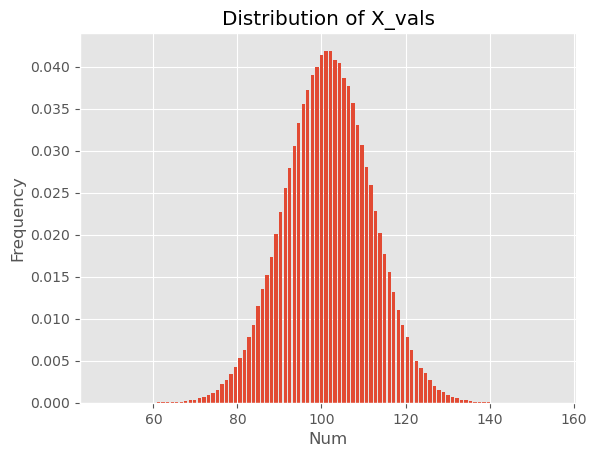

In [85]:
plt.bar(edges[0], X_vals)   #       
plt.ylabel('Frequency')
plt.xlabel('Num');
plt.title("Distribution of X_vals")
plt.show()

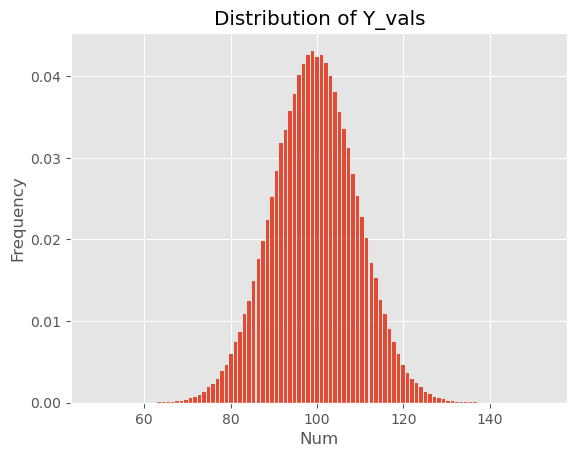

In [86]:
plt.bar(edges[1], Y_vals)   #       
plt.ylabel('Frequency')
plt.xlabel('Num');
plt.title("Distribution of Y_vals")
plt.show()

# Plotting table in 3-D

In [87]:
X = edges[0]
Y = edges[1]
X, Y = np.meshgrid(X, Y) # creates cartesian product of 2 vectors into: num_bins x num_bins 

Z = joint_probs / joint_probs.sum()

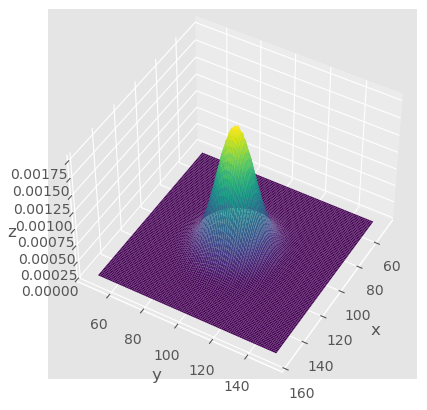

In [88]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis')

ax.view_init(45, 30)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

/tmp/ipykernel_9494/281636916.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  fig.colorbar(cp) # Add a colorbar to a plot


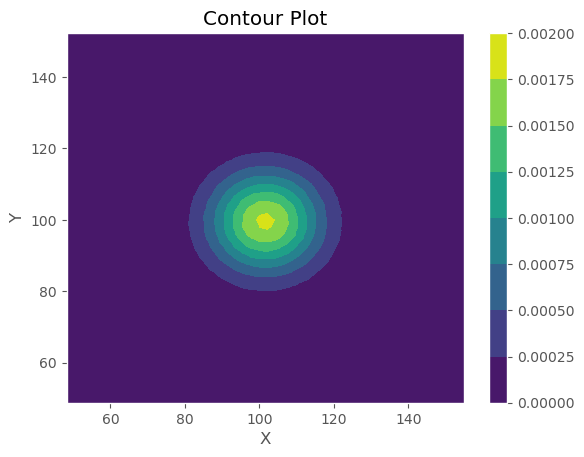

In [89]:
ig,ax = plt.subplots(1,1)
cp = ax.contourf(X, Y, Z)
fig.colorbar(cp) # Add a colorbar to a plot
ax.set_title('Contour Plot')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

Change in Y does effect on probability of 'X', \
on any intersection of the 3-D graph when the curve probability of X is normalized it always give same parabolla \
hence X is independent of Y!

# Dependence in Joints

In [91]:
import numpy as np

num_bins = 20   
num_samples = 10000

# Don't have to understand exactly how these values are being generated 
mean = [0, 0]
cov =  [[1, 0.8], 
        [0.8, 1.0]]  # diagonal covariance

data = 100 + 10 * np.random.multivariate_normal(mean, cov, num_samples)
joint_probs, edges = np.histogramdd(data, bins=num_bins)


edges = np.array(edges)[:,1:]
print(joint_probs)

[[  1.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  1.   0.   3.   1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   1.   5.   4.   2.   3.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  1.   1.   4.   9.  16.  19.   1.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   2.   6.  17.  32.  30.  25.   4.   4.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   7.  15.  53.  68.  65.  48.  26.   4.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   2.  14.  47.  91. 142. 129.  60.  23.   4.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   3.   6.  31.  83. 164. 247. 184.  98.  31.   3.   3.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   1.   2.  15.  57. 154. 297. 308. 185.  79.  16.   1.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   7.  24.  98. 266. 377. 351. 214

In [93]:
cut_point = 14    # try 9, 2 and 14 

X_vals = np.array(joint_probs[cut_point])
X_vals /= X_vals.sum() 

Y_vals = np.array( [row[cut_point] for row in joint_probs]  ) 
Y_vals /= Y_vals.sum()

In [94]:
print("Cut on X and Y on: ", cut_point)
print("Edges: ", edges[0])
print("X_vals: ", X_vals)
print("y_vals: ", Y_vals)

Cut on X and Y on:  14
Edges:  [ 64.45094614  68.22542291  71.99989968  75.77437644  79.54885321
  83.32332998  87.09780674  90.87228351  94.64676028  98.42123705
 102.19571381 105.97019058 109.74466735 113.51914412 117.29362088
 121.06809765 124.84257442 128.61705118 132.39152795 136.16600472]
X_vals:  [0.         0.         0.         0.         0.         0.
 0.         0.00227273 0.00454545 0.03181818 0.11818182 0.23409091
 0.29772727 0.18863636 0.09090909 0.02727273 0.00227273 0.00227273
 0.         0.        ]
y_vals:  [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.02083333 0.02083333
 0.08333333 0.19791667 0.20833333 0.21354167 0.16145833 0.05208333
 0.03125    0.01041667]


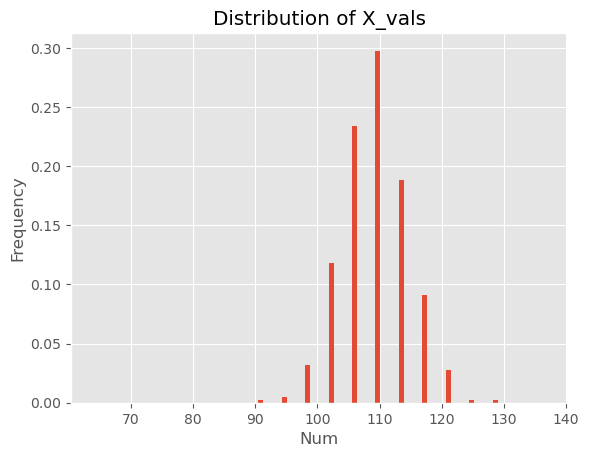

In [95]:
plt.bar(edges[0], X_vals)   #       
plt.ylabel('Frequency')
plt.xlabel('Num');
plt.title("Distribution of X_vals")
plt.show()

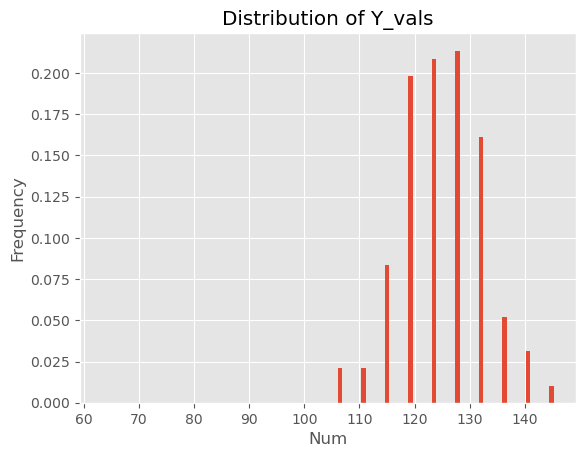

In [96]:
plt.bar(edges[1], Y_vals)   #       
plt.ylabel('Frequency')
plt.xlabel('Num');
plt.title("Distribution of Y_vals")
plt.show()

In [97]:
X = edges[0]
Y = edges[1]
X, Y = np.meshgrid(X, Y) # creates cartesian product of 2 vectors into: num_bins x num_bins 

Z = joint_probs / joint_probs.sum()

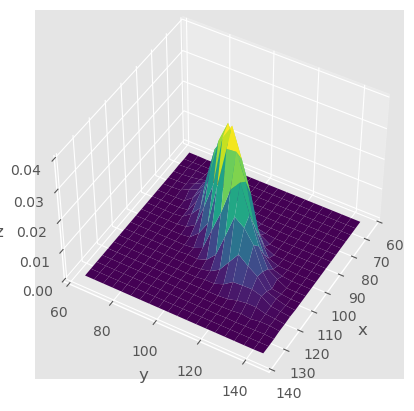

In [98]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis')

ax.view_init(45, 30)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

/tmp/ipykernel_9494/281636916.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  fig.colorbar(cp) # Add a colorbar to a plot


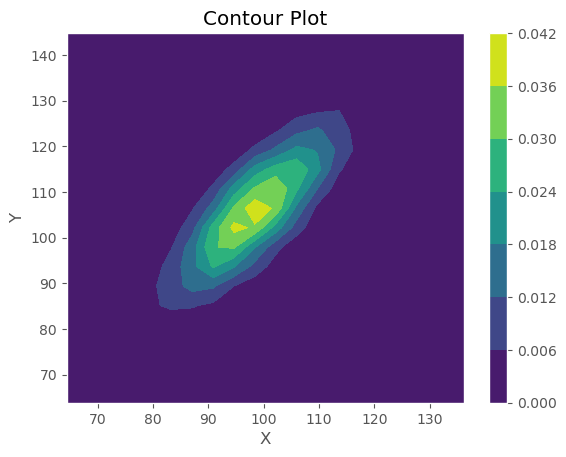

In [99]:
ig,ax = plt.subplots(1,1)
cp = ax.contourf(X, Y, Z)
fig.colorbar(cp) # Add a colorbar to a plot
ax.set_title('Contour Plot')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()